In [1]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip show pyarrow

Name: pyarrow
Version: 25.0.0
Summary: Python library for Apache Arrow
Home-page: https://arrow.apache.org/
Author: 
Author-email: 
License: 
Location: C:\intern-SLT\week 04\Broadband-Fraud-Management-System\venv\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

print(os.path.exists(r"real data\telecom_dataset_masked.parquet"))

False


In [4]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Isolation_forest_anomaly.csv', 'telecom_dataset_masked.csv', 'telecom_dataset_masked.parquet', 'telecom_dataset_with_mb.csv', 'Untitled.ipynb']


In [5]:
import pandas as pd

# Read the parquet file
df = pd.read_parquet("telecom_dataset_masked.parquet")

# Display the first 5 rows
print(df.head())

# Check dataset information
print(df.info())

# View column names
print(df.columns)

# Check the shape (rows, columns)
print(df.shape)

  subscriber_id record_opening_time record_closing_time  \
0   9441******* 2026-05-16 11:00:00 2026-05-16 10:00:00   
1   9491******* 2026-05-16 11:00:00 2026-05-16 10:00:00   
2     TG22***** 2026-05-16 11:00:00 2026-05-16 10:00:00   
3     KX28***** 2026-05-16 11:00:00 2026-05-16 10:00:00   
4   9445******* 2026-05-16 11:00:00 2026-05-16 10:00:00   

   cc_total_octets_bytes  cc_input_octets_bytes  cc_output_octets_bytes  \
0                      0                   8094                       0   
1                      0              104908831                 3101465   
2                      0                1265702                       0   
3                      0                  11306                       0   
4                      0              104970480                  576504   

        ymd           load_date   txn_ymd  
0  20260516 2026-05-17 05:04:50  20260516  
1  20260516 2026-05-17 05:04:50  20260516  
2  20260516 2026-05-17 05:04:50  20260516  
3  20260516 2026-0

In [6]:
df.head()

,subscriber_id,record_opening_time,record_closing_time,cc_total_octets_bytes,cc_input_octets_bytes,cc_output_octets_bytes,ymd,load_date,txn_ymd
0,9441*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,8094,0,20260516,2026-05-17 05:04:50,20260516
1,9491*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104908831,3101465,20260516,2026-05-17 05:04:50,20260516
2,TG22*****,2026-05-16 11:00:00,2026-05-16 10:00:00,0,1265702,0,20260516,2026-05-17 05:04:50,20260516
3,KX28*****,2026-05-16 11:00:00,2026-05-16 10:00:00,0,11306,0,20260516,2026-05-17 05:04:50,20260516
4,9445*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104970480,576504,20260516,2026-05-17 05:04:50,20260516


convert to csv file

In [7]:
import pandas as pd

# Read the Parquet file
df = pd.read_parquet("telecom_dataset_masked.parquet")

# Save as CSV
df.to_csv("telecom_dataset_masked.csv", index=False)

print("Dataset successfully converted to CSV!")

Dataset successfully converted to CSV!


bytes to mb

In [8]:
import pandas as pd

# Read the dataset
df = pd.read_parquet("telecom_dataset_masked.parquet")

# Convert bytes to MB
df["download_mb"] = df["cc_input_octets_bytes"] / (1024 * 1024)
df["upload_mb"] = df["cc_output_octets_bytes"] / (1024 * 1024)

# Calculate total usage in MB
df["total_usage_mb"] = df["download_mb"] + df["upload_mb"]

# Display the new columns
print(df[[
    "cc_input_octets_bytes",
    "cc_output_octets_bytes",
    "download_mb",
    "upload_mb",
    "total_usage_mb"
]].head())

   cc_input_octets_bytes  cc_output_octets_bytes  download_mb  upload_mb  \
0                   8094                       0     0.007719   0.000000   
1              104908831                 3101465   100.048858   2.957788   
2                1265702                       0     1.207067   0.000000   
3                  11306                       0     0.010782   0.000000   
4              104970480                  576504   100.107651   0.549797   

   total_usage_mb  
0        0.007719  
1      103.006645  
2        1.207067  
3        0.010782  
4      100.657448  


In [9]:
df.head()

,subscriber_id,record_opening_time,record_closing_time,cc_total_octets_bytes,cc_input_octets_bytes,cc_output_octets_bytes,ymd,load_date,txn_ymd,download_mb,upload_mb,total_usage_mb
0,9441*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,8094,0,20260516,2026-05-17 05:04:50,20260516,0.007719,0.000000,0.007719
1,9491*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104908831,3101465,20260516,2026-05-17 05:04:50,20260516,100.048858,2.957788,103.006645
2,TG22*****,2026-05-16 11:00:00,2026-05-16 10:00:00,0,1265702,0,20260516,2026-05-17 05:04:50,20260516,1.207067,0.000000,1.207067
3,KX28*****,2026-05-16 11:00:00,2026-05-16 10:00:00,0,11306,0,20260516,2026-05-17 05:04:50,20260516,0.010782,0.000000,0.010782
4,9445*******,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104970480,576504,20260516,2026-05-17 05:04:50,20260516,100.107651,0.549797,100.657448


csv with new columns

In [10]:
df.to_csv("telecom_dataset_with_mb.csv", index=False)

check missing values, data types

In [11]:
import pandas as pd

print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")
print("="*50)
print("Column Names")
print("="*50)
print(df.columns.tolist())

print("\n")
print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")
print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

Dataset Shape
(2700000, 12)


Column Names
['subscriber_id', 'record_opening_time', 'record_closing_time', 'cc_total_octets_bytes', 'cc_input_octets_bytes', 'cc_output_octets_bytes', 'ymd', 'load_date', 'txn_ymd', 'download_mb', 'upload_mb', 'total_usage_mb']


Data Types
subscriber_id                     object
record_opening_time       datetime64[ns]
record_closing_time       datetime64[ns]
cc_total_octets_bytes              int64
cc_input_octets_bytes              int64
cc_output_octets_bytes             int64
ymd                               object
load_date                 datetime64[ns]
txn_ymd                           object
download_mb                      float64
upload_mb                        float64
total_usage_mb                   float64
dtype: object


Missing Values
subscriber_id             0
record_opening_time       0
record_closing_time       0
cc_total_octets_bytes     0
cc_input_octets_bytes     0
cc_output_octets_bytes    0
ymd                       0
load_dat

In [12]:
print(df.describe())

                 record_opening_time            record_closing_time  \
count                        2700000                        2700000   
mean   2026-05-16 15:00:04.390665984  2026-05-17 20:25:25.037334272   
min              2026-05-16 00:00:00            2026-05-16 00:00:00   
25%              2026-05-16 11:00:00            2026-05-16 15:00:00   
50%              2026-05-16 15:00:00            2026-05-17 16:00:00   
75%              2026-05-16 20:00:00            2026-05-19 02:00:00   
max              2026-05-17 00:00:00            2026-05-19 23:00:00   
std                              NaN                            NaN   

       cc_total_octets_bytes  cc_input_octets_bytes  cc_output_octets_bytes  \
count           2.700000e+06           2.700000e+06            2.700000e+06   
mean            5.328874e+06           2.774687e+07            1.176710e+07   
min             0.000000e+00           0.000000e+00            0.000000e+00   
25%             0.000000e+00           0.000

In [13]:
print("Unique Subscribers:", df["subscriber_id"].nunique())

Unique Subscribers: 854


top 10 of total usage

In [14]:
top_users = (
    df.groupby("subscriber_id")["total_usage_mb"]
      .sum()
      .sort_values(ascending=False)
)

print(top_users.head(10))

subscriber_id
9411*******    4.597809e+07
9481*******    6.223639e+06
9433*******    5.424889e+06
9437*******    4.377399e+06
9491*******    4.317925e+06
9434*******    3.875102e+06
9431*******    3.595018e+06
9421*******    3.481210e+06
9438*******    2.813504e+06
9441*******    2.291445e+06
Name: total_usage_mb, dtype: float64


In [15]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


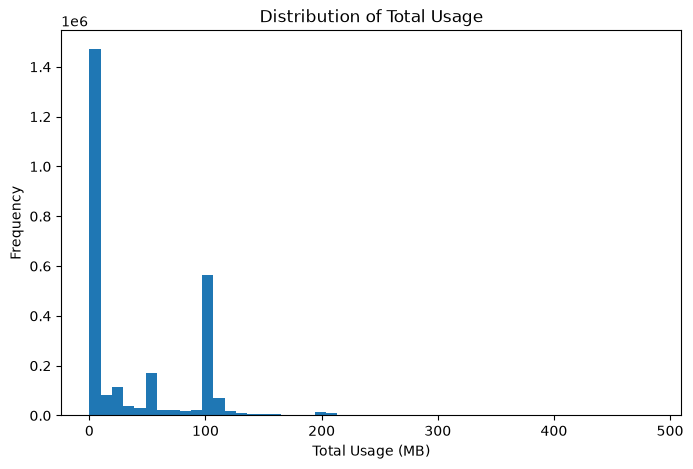

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["total_usage_mb"], bins=50)
plt.xlabel("Total Usage (MB)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Usage")
plt.show()

C:\Users\saras\AppData\Local\Temp\ipykernel_20872\1684009405.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["total_usage_mb"], vert=False)


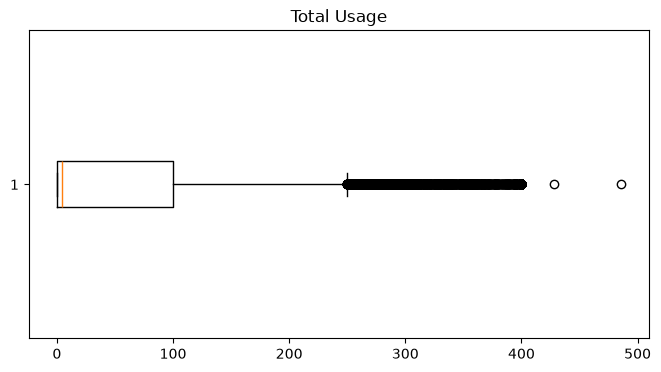

In [17]:
plt.figure(figsize=(8,4))
plt.boxplot(df["total_usage_mb"], vert=False)
plt.title("Total Usage")
plt.show()

In [18]:
print(df["total_usage_mb"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

0.50      4.463864
0.75    100.001326
0.90    103.810790
0.95    107.440353
0.99    195.118496
Name: total_usage_mb, dtype: float64


download mb Vs upload mb

In [19]:
print(df[[
    "download_mb",
    "upload_mb"
]].describe())

        download_mb     upload_mb
count  2.700000e+06  2.700000e+06
mean   2.646148e+01  1.122198e+01
std    4.337676e+01  2.696041e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    7.372494e-01  5.387650e-01
75%    4.942363e+01  3.697864e+00
max    4.135383e+02  4.853148e+02


In [20]:
daily_usage = (
    df.groupby(["subscriber_id", "ymd"])["total_usage_mb"]
      .sum()
)

print(daily_usage.describe())

count    8.540000e+02
mean     1.191397e+05
std      1.634381e+06
min      7.247925e-05
25%      1.302566e+02
50%      7.851795e+02
75%      4.819401e+03
max      4.597809e+07
Name: total_usage_mb, dtype: float64


In [21]:
sessions = (
    df.groupby("subscriber_id")
      .size()
)

print(sessions.describe())

count    8.540000e+02
mean     3.161593e+03
std      3.846459e+04
min      1.000000e+00
25%      7.250000e+00
50%      3.900000e+01
75%      2.502500e+02
max      1.066103e+06
dtype: float64


In [22]:
subscriber_profile = df.groupby("subscriber_id").agg(

    total_download_mb = ("download_mb","sum"),
    total_upload_mb = ("upload_mb","sum"),
    total_usage_mb = ("total_usage_mb","sum"),
    avg_usage_mb = ("total_usage_mb", 'mean'),
    max_usage_mb = ("total_usage_mb", "max"),
    Number_of_sessions = ("record_opening_time","count")
    

)

In [23]:
#disable scientific notation

pd.set_option('display.float_format', '{:.5f}'.format)

In [24]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
subscriber_id,,,,,,
****,95.65200,42.47976,138.13176,0.00611,15.77298,22614
9411*******,33269861.46405,12708231.86630,45978093.33034,43.12725,428.38101,1066103
9412******,3.82767,2.43918,6.26685,0.52224,3.08562,12
9412*******,100.03998,14.40394,114.44392,19.07399,114.21610,6
9421*******,2430421.12536,1050789.25490,3481210.38026,33.55028,400.00130,103761
...,...,...,...,...,...,...
WWT2******,581.95087,59.44166,641.39253,29.15421,204.64295,22
WY22*****,1440.16320,1331.68575,2771.84895,13.85924,104.19175,200
YA22*****,3607.50182,2828.05021,6435.55203,24.84769,237.31880,259


count how many records have the closing time after the opening time:

In [25]:
count = (df["record_closing_time"] > df["record_opening_time"]).sum()
print("closing time > Opening time ", count)

closing time > Opening time  2000694


In [26]:
count = (df["record_closing_time"] < df["record_opening_time"]).sum()
print("closing time < Opening time ", count)

closing time < Opening time  607898


In [27]:
subscriber_profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 854 entries, **** to YMH2******
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   total_download_mb   854 non-null    float64
 1   total_upload_mb     854 non-null    float64
 2   total_usage_mb      854 non-null    float64
 3   avg_usage_mb        854 non-null    float64
 4   max_usage_mb        854 non-null    float64
 5   Number_of_sessions  854 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 46.7+ KB


In [28]:
subscriber_profile.isnull().sum()

total_download_mb     0
total_upload_mb       0
total_usage_mb        0
avg_usage_mb          0
max_usage_mb          0
Number_of_sessions    0
dtype: int64

Check the distributions

In [29]:
subscriber_profile.describe().T

,count,mean,std,min,25%,50%,75%,max
total_download_mb,854.00000,83660.40513,1178611.09851,0.00000,50.08872,441.81950,2801.28268,33269861.46405
total_upload_mb,854.00000,35479.33772,456207.40147,0.00000,50.02449,340.63418,2090.60248,12708231.86630
total_usage_mb,854.00000,119139.74285,1634381.47097,0.00007,130.25662,785.17953,4819.40115,45978093.33034
avg_usage_mb,854.00000,20.93992,16.37362,0.00007,14.25090,19.14035,24.45078,214.34853
max_usage_mb,854.00000,117.70423,95.49911,0.00007,50.25393,73.40336,206.92593,485.31480
Number_of_sessions,854.00000,3161.59251,38464.59308,1.00000,7.25000,39.00000,250.25000,1066103.00000


Check feature correlations

In [30]:
subscriber_profile.corr()

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
total_download_mb,1.00000,0.99867,0.99990,0.07921,0.22001,0.99776
total_upload_mb,0.99867,1.00000,0.99931,0.08333,0.23658,0.99953
total_usage_mb,0.99990,0.99931,1.00000,0.08038,0.22469,0.99852
avg_usage_mb,0.07921,0.08333,0.08038,1.00000,0.37765,0.08415
max_usage_mb,0.22001,0.23658,0.22469,0.37765,1.00000,0.24430
Number_of_sessions,0.99776,0.99953,0.99852,0.08415,0.24430,1.00000


### Isolation Forest

Scale the features

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(subscriber_profile)
X_scaled.shape

(854, 6)

In [32]:
X_scaled

array([[-0.07094259, -0.0777226 , -0.07285407, -1.27925737, -1.06797834,
         0.50601878],
       [28.17354091, 27.79476759, 28.07534686,  1.35585981,  3.25509663,
        27.65047543],
       [-0.07102054, -0.07781042, -0.0729348 , -1.24771689, -1.20090931,
        -0.08193088],
       ...,
       [-0.06796119, -0.07161309, -0.06899872,  0.23880258,  1.25325425,
        -0.07550563],
       [-0.07092988, -0.07739955, -0.07275474,  0.13241203, -0.14531447,
        -0.08190487],
       [-0.06961383, -0.07304071, -0.07058899, -0.35625745, -0.12909176,
        -0.0756357 ]])

Train Isolation Forest

In [33]:
#Start with 1% contamination. This means we assume about 1% of subscribers are anomalous.
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators = 100,
    contamination = 0.01,
    random_state = 42
)

model.fit(X_scaled)

IsolationForest(contamination=0.01, random_state=42)

Predict anomalies

In [34]:
subscriber_profile["anomaly"] = model.predict(X_scaled)
subscriber_profile["anomaly"]

subscriber_id
****           1
9411*******   -1
9412******     1
9412*******    1
9421*******   -1
              ..
WWT2******     1
WY22*****      1
YA22*****      1
YGO2******     1
YMH2******     1
Name: anomaly, Length: 854, dtype: int32

In [35]:
subscriber_profile["anomaly"].value_counts()

anomaly
 1    845
-1      9
Name: count, dtype: int64

all anomaly with id

Compute anomaly scores

In [36]:
subscriber_profile["anomaly_score"] = model.decision_function(X_scaled)

Sort by anomaly score

In [37]:
subscriber_profile.sort_values(
    by = "anomaly_score"
)

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score
subscriber_id,,,,,,,,
9411*******,33269861.46405,12708231.86630,45978093.33034,43.12725,428.38101,1066103,-1,-0.11057
9481*******,4389184.47475,1834454.67185,6223639.14660,37.11772,485.31480,167673,-1,-0.07631
9433*******,3682936.37809,1741952.33016,5424888.70826,37.02187,400.00087,146532,-1,-0.06268
9437*******,2982093.10427,1395306.10208,4377399.20635,34.77825,400.00122,125866,-1,-0.04927
9491*******,3069106.02617,1248819.12713,4317925.15330,40.05608,400.00131,107797,-1,-0.04821
...,...,...,...,...,...,...,...,...
MDE2******,133.67919,157.05377,290.73297,19.38220,51.59051,15,1,0.40153
DVN2******,142.72526,203.43883,346.16410,20.36259,50.09457,17,1,0.40160
GOH2******,134.73272,254.91883,389.65155,20.50798,52.74191,19,1,0.40163


Create a fraud label

In [38]:
subscriber_profile["fraud_status"] = subscriber_profile["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [39]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score,fraud_status
subscriber_id,,,,,,,,,
****,95.65200,42.47976,138.13176,0.00611,15.77298,22614,1,0.17028,Normal
9411*******,33269861.46405,12708231.86630,45978093.33034,43.12725,428.38101,1066103,-1,-0.11057,Anomaly
9412******,3.82767,2.43918,6.26685,0.52224,3.08562,12,1,0.32571,Normal
9412*******,100.03998,14.40394,114.44392,19.07399,114.21610,6,1,0.37196,Normal
9421*******,2430421.12536,1050789.25490,3481210.38026,33.55028,400.00130,103761,-1,-0.02888,Anomaly
...,...,...,...,...,...,...,...,...,...
WWT2******,581.95087,59.44166,641.39253,29.15421,204.64295,22,1,0.37273,Normal
WY22*****,1440.16320,1331.68575,2771.84895,13.85924,104.19175,200,1,0.35786,Normal
YA22*****,3607.50182,2828.05021,6435.55203,24.84769,237.31880,259,1,0.34506,Normal


Save the results

In [40]:
subscriber_profile.to_csv(
    "Isolation_forest_anomaly.csv"
)

### Local Outlier Factor (LOF)

In [42]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(
    n_neighbors = 20,
    contamination = 0.01
)

pred = lof.fit_predict(X_scaled)

subscriber_profile["lof_anomaly"] = pred
subscriber_profile["lof_score"] = lof.negative_outlier_factor_

Convert labels

In [43]:
subscriber_profile["lof_status"] = subscriber_profile["lof_anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

Count anomalies

In [44]:
subscriber_profile["lof_anomaly"].value_counts()

lof_anomaly
 1    845
-1      9
Name: count, dtype: int64

### One-Class SVM

In [47]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(
    kernel = "rbf",
    gamma = "scale",
    nu = 0.01
)

svm.fit(X_scaled)

subscriber_profile["svm_anomaly"] = svm.predict(X_scaled)
subscriber_profile["svm_score"] = svm.decision_function(X_scaled)

Convert labels

In [48]:
subscriber_profile["svm_status"] = subscriber_profile["svm_anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

Count anomalies

In [49]:
subscriber_profile["svm_anomaly"].value_counts()

svm_anomaly
 1    818
-1     36
Name: count, dtype: int64

### DBSCAN

In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps = 0.7,
    min_samples = 10  )
labels = dbscan.fit_predict(X_scaled)

subscriber_profile["dbscan_cluster"] = labels

Create status

In [53]:
subscriber_profile["dbscan_status"] = subscriber_profile["dbscan_cluster"].apply(
    lambda x: "Anomaly" if x== -1 else "Normal"
)

Count anomalies

In [54]:
subscriber_profile["dbscan_status"].value_counts()

dbscan_status
Normal     834
Anomaly     20
Name: count, dtype: int64

### Elliptic Envelope

In [55]:
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(
    contamination = 0.01,
    random_state = 42
)

ee.fit(X_scaled)

subscriber_profile["ee_anomaly"] = ee.predict(X_scaled)
subscriber_profile["ee_score"] = ee.decision_function(X_scaled)

C:\intern-SLT\week 04\Broadband-Fraud-Management-System\venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:748: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
C:\intern-SLT\week 04\Broadband-Fraud-Management-System\venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-108.258216873120631 > -108.410787908662570). You may want to try with a higher value of support_fraction (current value: 0.505).
  warnings.warn(


Convert Label

In [57]:
subscriber_profile["ee_status"] = subscriber_profile["ee_anomaly"].map({
    1:"Noarmal",
    -1:"Anomaly"
})

Count anomalies

In [58]:
subscriber_profile["ee_status"].value_counts()

ee_status
Noarmal    845
Anomaly      9
Name: count, dtype: int64

#### Comparison Table

In [59]:
comparison = {
    "Isolation Forest":
        (subscriber_profile["anomaly"] == -1).sum(),
    "LOF":
        (subscriber_profile["lof_anomaly"] == -1).sum(),
    "One-Class SVM":
        (subscriber_profile["svm_anomaly"] == -1).sum(),
    "DBSCAN":
        (subscriber_profile["dbscan_cluster"] == -1).sum(),
    "Elliptic Envelope":
        (subscriber_profile["ee_anomaly"] == -1).sum()
}

comparison_df = pd.DataFrame.from_dict(
    comparison,
    orient = "index",
    columns = ["Detected Anomalies"]
)

comparison_df

,Detected Anomalies
Isolation Forest,9
LOF,9
One-Class SVM,36
DBSCAN,20
Elliptic Envelope,9


#### Compare Which Subscribers Were Detected

In [68]:
comparison = pd.DataFrame(index=subscriber_profile.index)

comparison["Isolation Forest"] = subscriber_profile["anomaly"]
comparison["LOF"] = subscriber_profile["lof_anomaly"]
comparison["One-Class SVM"] = subscriber_profile["svm_anomaly"]
comparison["DBSCAN"] = subscriber_profile["dbscan_cluster"].apply(lambda x: -1 if x == -1 else 1)
comparison["Elliptic Envelope"] = subscriber_profile["ee_anomaly"]

comparison

,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope
subscriber_id,,,,,
****,1,-1,-1,1,1
9411*******,-1,-1,-1,-1,-1
9412******,1,1,1,1,1
9412*******,1,1,1,1,1
9421*******,-1,1,1,-1,-1
...,...,...,...,...,...
WWT2******,1,1,1,1,1
WY22*****,1,1,1,1,1
YA22*****,1,1,1,1,1


all subscribers detected by at least one algorithm

In [64]:
all_anomalies = comparison[
    (comparison["Isolation Forest"] == -1) |
    (comparison["LOF"] == -1) |
    (comparison["One-Class SVM"] == -1) |
    (comparison["DBSCAN"] == -1) |
    (comparison["Elliptic Envelope"] == -1)
]

all_anomalies

,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope
subscriber_id,,,,,
****,1,-1,-1,1,1
9411*******,-1,-1,-1,-1,-1
9421*******,-1,1,1,-1,-1
9431*******,-1,1,1,-1,-1
9433*******,-1,1,1,-1,-1
9434*******,-1,1,1,-1,-1
9437*******,-1,1,1,-1,-1
9438*******,-1,1,-1,-1,-1
9441*******,1,1,1,-1,1


how many algorithms flagged each subscriber

In [65]:
comparison["Algorithms_Flagged"] = (
    (comparison == -1).sum(axis=1)
)

comparison.sort_values(
    by="Algorithms_Flagged",
    ascending=False
)

,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope,Algorithms_Flagged
subscriber_id,,,,,,
9411*******,-1,-1,-1,-1,-1,5
9438*******,-1,1,-1,-1,-1,4
9491*******,-1,1,-1,-1,-1,4
9433*******,-1,1,1,-1,-1,3
D947**,1,-1,-1,-1,1,3
...,...,...,...,...,...,...
HKT2******,1,1,1,1,1,0
HM22*****,1,1,1,1,1,0
HMT2******,1,1,1,1,1,0


high-confidence anomalies

In [66]:
high_confidence = comparison[
    comparison["Algorithms_Flagged"] >= 3
]

high_confidence

,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope,Algorithms_Flagged
subscriber_id,,,,,,
9411*******,-1,-1,-1,-1,-1,5
9421*******,-1,1,1,-1,-1,3
9431*******,-1,1,1,-1,-1,3
9433*******,-1,1,1,-1,-1,3
9434*******,-1,1,1,-1,-1,3
9437*******,-1,1,1,-1,-1,3
9438*******,-1,1,-1,-1,-1,4
9481*******,-1,1,1,-1,-1,3
9491*******,-1,1,-1,-1,-1,4


In [69]:
comparison = subscriber_profile.copy()

comparison["Isolation Forest"] = subscriber_profile["anomaly"]
comparison["LOF"] = subscriber_profile["lof_anomaly"]
comparison["One-Class SVM"] = subscriber_profile["svm_anomaly"]
comparison["DBSCAN"] = subscriber_profile["dbscan_cluster"].apply(lambda x: -1 if x == -1 else 1)
comparison["Elliptic Envelope"] = subscriber_profile["ee_anomaly"]

comparison["Algorithms_Flagged"] = (
    comparison[[
        "Isolation Forest",
        "LOF",
        "One-Class SVM",
        "DBSCAN",
        "Elliptic Envelope"
    ]] == -1
).sum(axis=1)

comparison.sort_values(
    by="Algorithms_Flagged",
    ascending=False
)

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score,fraud_status,lof_anomaly,...,dbscan_status,ee_anomaly,ee_score,ee_status,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope,Algorithms_Flagged
subscriber_id,,,,,,,,,,,,,,,,,,,,,
9411*******,33269861.46405,12708231.86630,45978093.33034,43.12725,428.38101,1066103,-1,-0.11057,Anomaly,-1,...,Anomaly,-1,-18002354947.21778,Anomaly,-1,-1,-1,-1,-1,5
9438*******,1866697.17684,946806.59357,2813503.77041,36.73269,400.00096,76594,-1,-0.00557,Anomaly,1,...,Anomaly,-1,-7396006.35501,Anomaly,-1,1,-1,-1,-1,4
9491*******,3069106.02617,1248819.12713,4317925.15330,40.05608,400.00131,107797,-1,-0.04821,Anomaly,1,...,Anomaly,-1,-98907980.13684,Anomaly,-1,1,-1,-1,-1,4
9433*******,3682936.37809,1741952.33016,5424888.70826,37.02187,400.00087,146532,-1,-0.06268,Anomaly,1,...,Anomaly,-1,-153359090.63062,Anomaly,-1,1,1,-1,-1,3
D947**,4032.32216,282.83982,4315.16199,134.84881,232.33573,32,1,0.14179,Normal,-1,...,Anomaly,1,44788280.70139,Noarmal,1,-1,-1,-1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HKT2******,3430.08019,3045.33052,6475.41072,22.25227,207.98429,291,1,0.36199,Normal,1,...,Normal,1,44788556.05253,Noarmal,1,1,1,1,1,0
HM22*****,4876.41823,2699.89521,7576.31344,23.31173,282.07657,325,1,0.31548,Normal,1,...,Normal,1,44788507.48916,Noarmal,1,1,1,1,1,0
HMT2******,2686.95028,3547.27102,6234.22130,19.91764,210.09994,313,1,0.36299,Normal,1,...,Normal,1,44788544.19070,Noarmal,1,1,1,1,1,0


anomalous subscribers

In [70]:
comparison_anomalies = comparison[
    comparison["Algorithms_Flagged"] > 0
].sort_values(
    by="Algorithms_Flagged",
    ascending=False
)

comparison_anomalies

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score,fraud_status,lof_anomaly,...,dbscan_status,ee_anomaly,ee_score,ee_status,Isolation Forest,LOF,One-Class SVM,DBSCAN,Elliptic Envelope,Algorithms_Flagged
subscriber_id,,,,,,,,,,,,,,,,,,,,,
9411*******,33269861.46405,12708231.86630,45978093.33034,43.12725,428.38101,1066103,-1,-0.11057,Anomaly,-1,...,Anomaly,-1,-18002354947.21778,Anomaly,-1,-1,-1,-1,-1,5
9438*******,1866697.17684,946806.59357,2813503.77041,36.73269,400.00096,76594,-1,-0.00557,Anomaly,1,...,Anomaly,-1,-7396006.35501,Anomaly,-1,1,-1,-1,-1,4
9491*******,3069106.02617,1248819.12713,4317925.15330,40.05608,400.00131,107797,-1,-0.04821,Anomaly,1,...,Anomaly,-1,-98907980.13684,Anomaly,-1,1,-1,-1,-1,4
D947**,4032.32216,282.83982,4315.16199,134.84881,232.33573,32,1,0.14179,Normal,-1,...,Anomaly,1,44788280.70139,Noarmal,1,-1,-1,-1,1,3
9421*******,2430421.12536,1050789.25490,3481210.38026,33.55028,400.00130,103761,-1,-0.02888,Anomaly,1,...,Anomaly,-1,-26537906.35153,Anomaly,-1,1,1,-1,-1,3
9431*******,2439876.82082,1155141.17729,3595017.99812,36.74310,400.00074,97842,-1,-0.02940,Anomaly,1,...,Anomaly,-1,-41197039.45302,Anomaly,-1,1,1,-1,-1,3
9433*******,3682936.37809,1741952.33016,5424888.70826,37.02187,400.00087,146532,-1,-0.06268,Anomaly,1,...,Anomaly,-1,-153359090.63062,Anomaly,-1,1,1,-1,-1,3
9434*******,2552515.08914,1322586.51902,3875101.60816,34.95302,400.00229,110866,-1,-0.03826,Anomaly,1,...,Anomaly,-1,-46365090.28082,Anomaly,-1,1,1,-1,-1,3
9437*******,2982093.10427,1395306.10208,4377399.20635,34.77825,400.00122,125866,-1,-0.04927,Anomaly,1,...,Anomaly,-1,-72432712.43022,Anomaly,-1,1,1,-1,-1,3


In [71]:
comparison_anomalies.to_csv(
    "comparison_anomalies.csv",
    index=True
)